In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nskernel import NonStationaryKernel
from scipy.optimize import fmin_l_bfgs_b
from spleaf import cov, term
import scipy.io as sp
import emcee


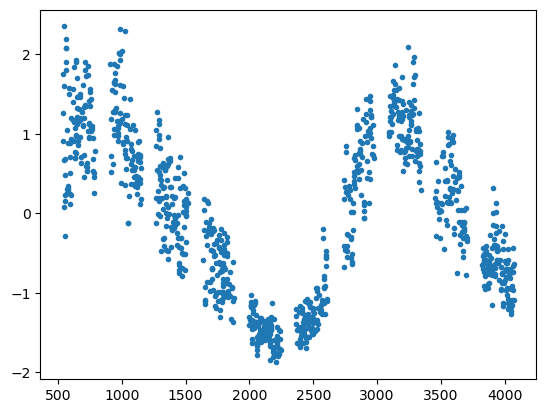

In [2]:
realis = 2
use_file = f"serie_res_bt_G2_1000_4m_NOISE0.09_OGS_MAG_M1_real{realis}.sav"
data = sp.readsav(use_file)

arr_len = len(data['tt'])
tt = data['tt']
rv = data['rv']
rhk = data['ca']
erv = np.zeros(len(rhk))+0.09
rhk_err = np.zeros(len(rhk))+5e-4

rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

# RHK normalization
rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std

# erv_norm *=50
# rhk_err_norm *=50

T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

plt.plot(tt, rv_norm, ".")

In [3]:
# def alpha(t, a1, a2, b1, b2, pcyc):
#   fc = a1 * np.sin(2.0 * np.pi * t / pcyc) + a2 * np.cos(2.0 * np.pi * t / pcyc) + b1 * np.sin(4.0 * np.pi * t / pcyc) + b2 * np.cos(4.0 * np.pi * t / pcyc) 
#   R1 = np.sqrt(a1**2 + a2**2)
#   R2 = np.sqrt(b1**2 + b2**2)
#   Amax = R1 + R2

#   return (fc - (-Amax)) / (2 * Amax + 1e-14)

def alpha(t, a1, a2, pcyc):
  fc = a1 * np.sin(2.0 * np.pi * t / pcyc) + a2 * np.cos(2.0 * np.pi * t / pcyc) 
  R1 = np.sqrt(a1**2 + a2**2)
  Amax = R1 

  return (fc - (-Amax)) / (2 * Amax + 1e-14)

# def alpha_grad(t, a1, a2, b1, b2, c, pcyc):

#     k = 2.0 * np.pi / pcyc

#     grad_a1 = np.sin(k * t)
#     grad_a2 = np.cos(k * t)
#     grad_b1 = np.sin(2 * k * t)
#     grad_b2 = np.cos(2 * k * t)
#     grad_c  = np.ones_like(t)
#     grad_pcyc = k*t/pcyc * (a2*np.sin(k*t) - a1*np.cos(k*t) + 2*b2*np.sin(2*k*t) - 2*b1*np.cos(2*k*t))

#     return {
#         'a1': grad_a1,
#         'a2': grad_a2,
#         'b1': grad_b1,
#         'b2': grad_b2,
#         'c':  grad_c,
#         'pcyc': grad_pcyc
#     }

# def alpha_grad(t, a1, a2, b1, b2, pcyc):
#     k = 2.0 * np.pi / pcyc
#     s1 = np.sin(k * t)
#     c1 = np.cos(k * t)
#     s2 = np.sin(2*k * t)
#     c2 = np.cos(2*k * t)

#     # raw fc
#     fc = a1*s1 + a2*c1 + b1*s2 + b2*c2

#     # R1, R2 and Amax
#     R1 = np.sqrt(a1*a1 + a2*a2)
#     R2 = np.sqrt(b1*b1 + b2*b2)
#     Amax = R1 + R2
#     eps = 1e-8
#     D = 2.0 * Amax + eps   # denominator

#     # partials of fc wrt params
#     dfc = {
#         'a1': s1,
#         'a2': c1,
#         'b1': s2,
#         'b2': c2
#     }

#     # partials of Amax wrt params (handle near-zero R1/R2)
#     dR1 = {'a1': (a1 / (R1 + 1e-12)), 'a2': (a2 / (R1 + 1e-12))}
#     dR2 = {'b1': (b1 / (R2 + 1e-12)), 'b2': (b2 / (R2 + 1e-12))}
#     dA = {
#         'a1': dR1['a1'],
#         'a2': dR1['a2'],
#         'b1': dR2['b1'],
#         'b2': dR2['b2']
#     }

#     # numerator = fc - (c - Amax) = fc - c + Amax
#     numer = fc + Amax

#     grads = {}
#     for pname in ('a1','a2','b1','b2'):
#         df = dfc[pname]                # ∂fc/∂p
#         dA_dp = dA[pname]              # ∂Amax/∂p (scalar)
#         # D = 2 * Amax + eps  => dD_dp = 2 * dA_dp
#         dD_dp = 2.0 * dA_dp

#         # d(alpha) = ( (df + dA_dp) * D - numer * dD_dp ) / D^2
#         grads[pname] = ((df + dA_dp) * D - numer * dD_dp) / (D*D)

#     # gradient w.r.t pcyc (needs derivative of fc wrt pcyc; fairly small)
#     # dfc/dpcyc = derivative via k=2pi/pcyc: dk/dpcyc = -2pi / pcyc^2
#     dk_dp = -2.0 * np.pi / (pcyc**2)
#     df_dpcyc = a1 * (t * np.cos(k*t)) * dk_dp + \
#                a2 * (-t * np.sin(k*t)) * dk_dp + \
#                b1 * (2*t * np.cos(2*k*t)) * dk_dp + \
#                b2 * (-2*t * np.sin(2*k*t)) * dk_dp
#     # similarly dA/dpcyc = 0 because Amax doesn't depend on pcyc
#     grads['pcyc'] = (df_dpcyc * D - numer * 0.0) / (D*D)

#     return grads

def alpha_grad(t, a1, a2, pcyc):
    k = 2.0 * np.pi / pcyc
    s1 = np.sin(k * t)
    c1 = np.cos(k * t)
    s2 = np.sin(2*k * t)
    c2 = np.cos(2*k * t)

    # raw fc
    fc = a1*s1 + a2*c1 

    # R1, R2 and Amax
    R1 = np.sqrt(a1*a1 + a2*a2)
    Amax = R1 
    eps = 1e-8
    D = 2.0 * Amax + eps   # denominator

    # partials of fc wrt params
    dfc = {
        'a1': s1,
        'a2': c1
    }

    # partials of Amax wrt params (handle near-zero R1/R2)
    dR1 = {'a1': (a1 / (R1 + 1e-12)), 'a2': (a2 / (R1 + 1e-12))}
    dA = {
        'a1': dR1['a1'],
        'a2': dR1['a2'],

    }

    # numerator = fc - (c - Amax) = fc - c + Amax
    numer = fc + Amax

    grads = {}
    for pname in ('a1','a2'):
        df = dfc[pname]                # ∂fc/∂p
        dA_dp = dA[pname]              # ∂Amax/∂p (scalar)
        # D = 2 * Amax + eps  => dD_dp = 2 * dA_dp
        dD_dp = 2.0 * dA_dp

        # d(alpha) = ( (df + dA_dp) * D - numer * dD_dp ) / D^2
        grads[pname] = ((df + dA_dp) * D - numer * dD_dp) / (D*D)

    # gradient w.r.t pcyc (needs derivative of fc wrt pcyc; fairly small)
    # dfc/dpcyc = derivative via k=2pi/pcyc: dk/dpcyc = -2pi / pcyc^2
    dk_dp = -2.0 * np.pi / (pcyc**2)
    df_dpcyc = a1 * (t * np.cos(k*t)) * dk_dp + \
               a2 * (-t * np.sin(k*t)) * dk_dp
    # similarly dA/dpcyc = 0 because Amax doesn't depend on pcyc
    grads['pcyc'] = (df_dpcyc * D - numer * 0.0) / (D*D)

    return grads



In [6]:
stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 20.0
Q = 0.5

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

a1, a2,  pcyc = 0.5, -6.1, 2500.0

# C = cov.Cov(
#   t_full,
#   err=term.Error(yerr_full),
#   rv_jit=term.InstrumentJitter(series_index[0], rvjit),
#   rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
#   gp= term.SimpleProductKernel(
#     nonstat=MultiSeriesKernelPatched(NonStationaryKernel(alpha, alpha_grad, a1=a1, a2=a2, b1=b1, b2=b2, c=c, pcyc=pcyc),series_index, 
#         np.ones(2) * stds, 
#         np.array([stds[0], 0.0])), 
#     rot = 
#         MultiSeriesKernelPatched(term.SHOKernel( # this term represents the rotation
#                 sig, # st.dev. sig (should be 1)
#                 prot, # period P, in days
#                 Q, # quality factor Q
#         ), series_index, 
#         np.ones(2) * stds, 
#         np.array([stds[0], 0.0])
#     ),
#   )
# )

C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  gp=term.MultiSeriesKernel(term.SimpleProductKernel(
    nonstat=NonStationaryKernel(alpha, alpha_grad, a1=a1, a2=a2, pcyc=pcyc), 
    rot = term.SHOKernel( # this term represents the rotation
                sig, # st.dev. sig (should be 1)
                prot, # period P, in days
                Q, # quality factor Q
        )), series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  )



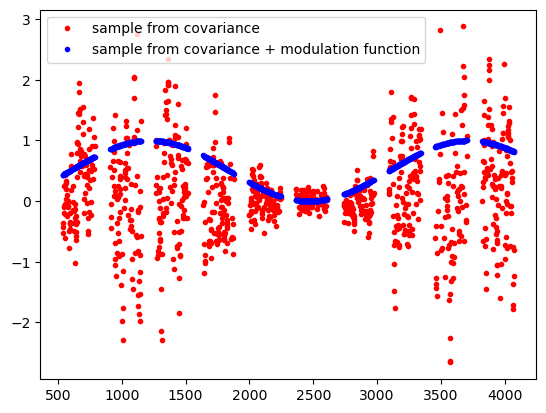

In [7]:
fc_norm = alpha(t_full[series_index[0]], a1, a2, pcyc)
drawn_sample = C.sample()[series_index[0]]

plt.plot(t_full[series_index[0]], drawn_sample, ".", color="red", label="sample from covariance")
plt.plot(t_full[series_index[0]], fc_norm, ".", color="blue", label="sample from covariance + modulation function")
plt.legend()

In [8]:
rvjit_max = 4*stds[0]
rhkjit_max = 4*stds[1]

prot_min = 17.0
prot_max = 25.0
Q_min = 0.01
Q_max = 5.0

pcyc_min = 2000.0
pcyc_max = 3000.0

alpha_0_max = 4*stds[0]
alpha_1_max = 4*stds[1]
beta_0_max  = 4*stds[0]
beta_1_max  = 4*stds[1]
gamma_0_max = 4*stds[0]
gamma_1_max = 4*stds[1]

bounds_list = [
    (0.001, rvjit_max),                     # rv_jit.sig
    (0.001, rhkjit_max),                     # rhk_jit.sig
    (-10,10),
    (-10,10),
    # (-10,10),
    # (-10,10),
    (pcyc_min, pcyc_max),     
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
    (-gamma_0_max, gamma_0_max),         # rot.gamma_0
    (-gamma_1_max, gamma_1_max),         # rot.gamma_1
]

C.param

['rv_jit.sig',
 'rhk_jit.sig',
 'gp.nonstat_a1',
 'gp.nonstat_a2',
 'gp.nonstat_pcyc',
 'gp.rot_sig',
 'gp.rot_P0',
 'gp.rot_Q',
 'gp.alpha_0',
 'gp.alpha_1',
 'gp.beta_0',
 'gp.beta_1']

In [9]:
fitted = [k for k, key in enumerate(C.param) if key != 'gp.rot_sig' and key != "gp.beta_1"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)

x0 = np.append(x0,[0.0,0.0])

def negloglike(x, y, C):
  C.set_param(x[:len(params)], params)
  fc = alpha(t_full, x[2],x[3],x[4])
  y_model = y.copy()
  y_model[series_index[0]] -= x[-2]*fc[series_index[0]]
  y_model[series_index[1]] -= x[-1]*fc[series_index[1]]
  nll = -C.loglike(y_model)
  # gradient
  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  grad_gamma_0 = np.sum(dL_dy[series_index[0]] * fc[series_index[0]])
  grad_gamma_1 = np.sum(dL_dy[series_index[1]] * fc[series_index[1]])

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_gamma_0, grad_gamma_1])])


  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)



result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest, params)
C.set_param([0.0], ['gp.beta_1'])

print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_a1', 'gp.nonstat_a2', 'gp.nonstat_pcyc', 'gp.rot_P0', 'gp.rot_Q', 'gp.alpha_0', 'gp.alpha_1', 'gp.beta_0']
[ 2.70208172e-01  1.74547349e-01 -3.92254507e+00 -8.34362519e+00
  2.54401064e+03  2.50000000e+01  1.00000000e-02  3.90484424e+00
  4.00000000e+00  1.69138597e-03  2.31714453e-01  3.35003039e-01]


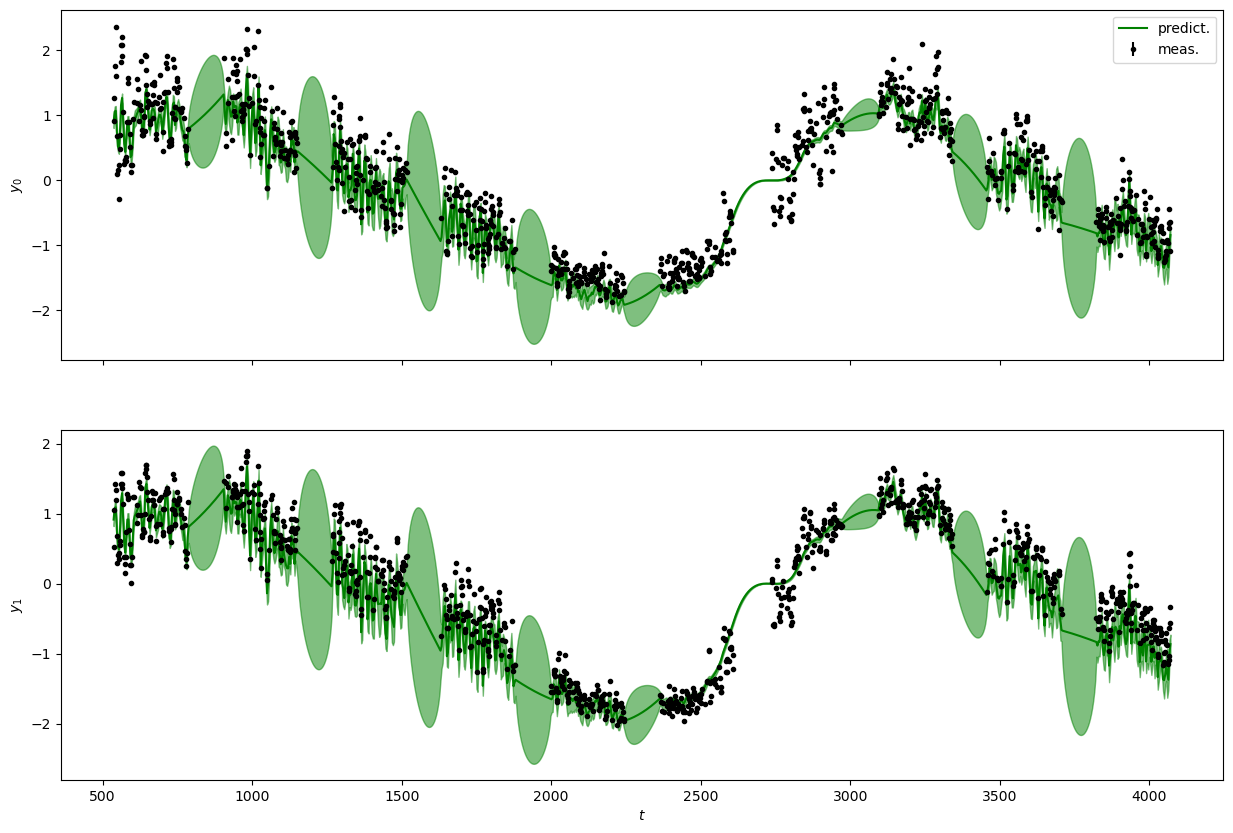

In [10]:
# C.set_param([0.0], ['gp.beta_0'])  
# C.set_param(xbest)

# C.set_param(samples[-1,0,:], params)

tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  fc = alpha(t_full, xbest[2],xbest[3],xbest[4])

  y_model = y_full.copy()
  y_model[series_index[0]] -= xbest[-2]*fc[series_index[0]]
  y_model[series_index[1]] -= xbest[-1]*fc[series_index[1]]

  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  ax.errorbar(T[k], Y[k], Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [9]:
def log_prior(theta):
    rv_jit, rhk_jit, a1, a2,pcyc, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1 = theta
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and -10 < a1 < 10 and -10 < a2 < 10 and pcyc_min < pcyc < pcyc_max and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and -gamma_0_max < gamma_0 < gamma_0_max and -gamma_1_max < gamma_1 < gamma_1_max:
    # if 0 < rv_jit < rvjit_max and 0 < rhk_jit < rhkjit_max and p1_min < cyc_P0 < p1_max and 0.0 < cyc_alpha_0 < alpha_0_max and -1*stds[1] < cyc_alpha_1 < alpha_1_max:    
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[ 2.70208172e-01  1.74547349e-01 -3.92254507e+00 -8.34362519e+00
  2.54401064e+03  2.50000000e+01  1.00000000e-02  3.90484424e+00
  4.00000000e+00  1.69138597e-03  2.31714453e-01  3.35003039e-01]
-inf


  0%|          | 0/2000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [00:46<00:00, 42.86it/s]


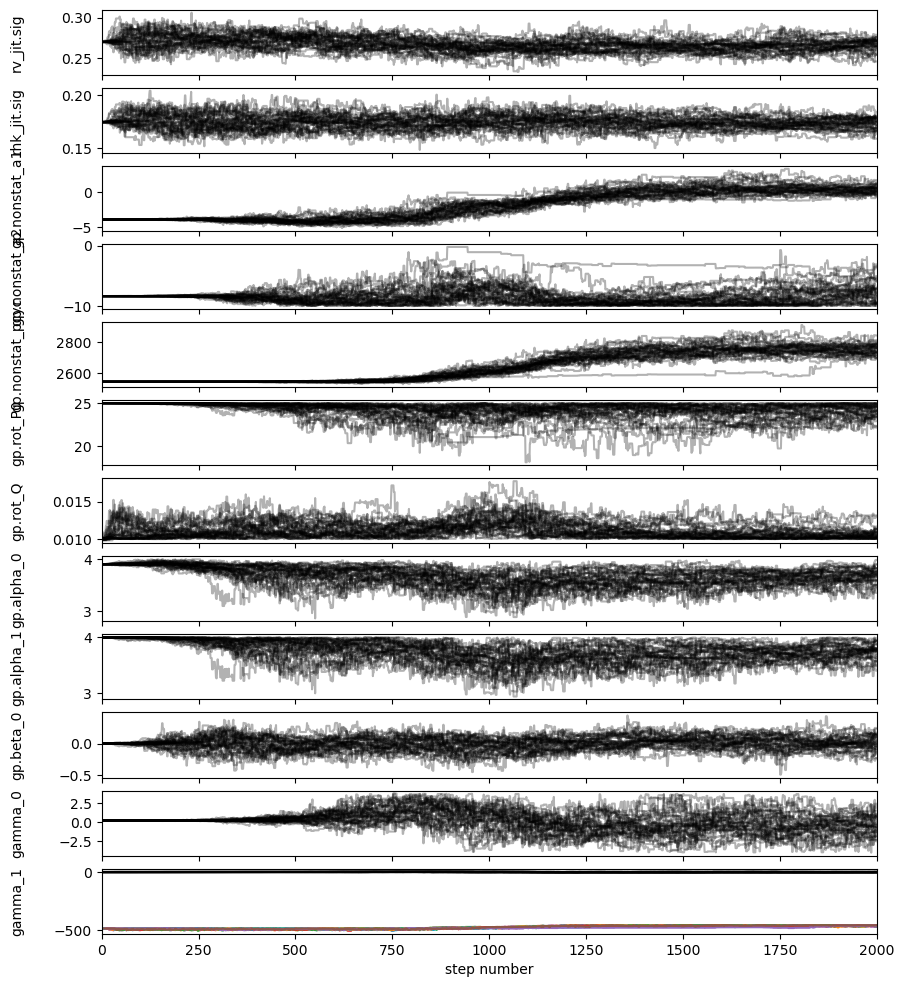

In [10]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 2, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()
labels = params + ['gamma_0', 'gamma_1']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

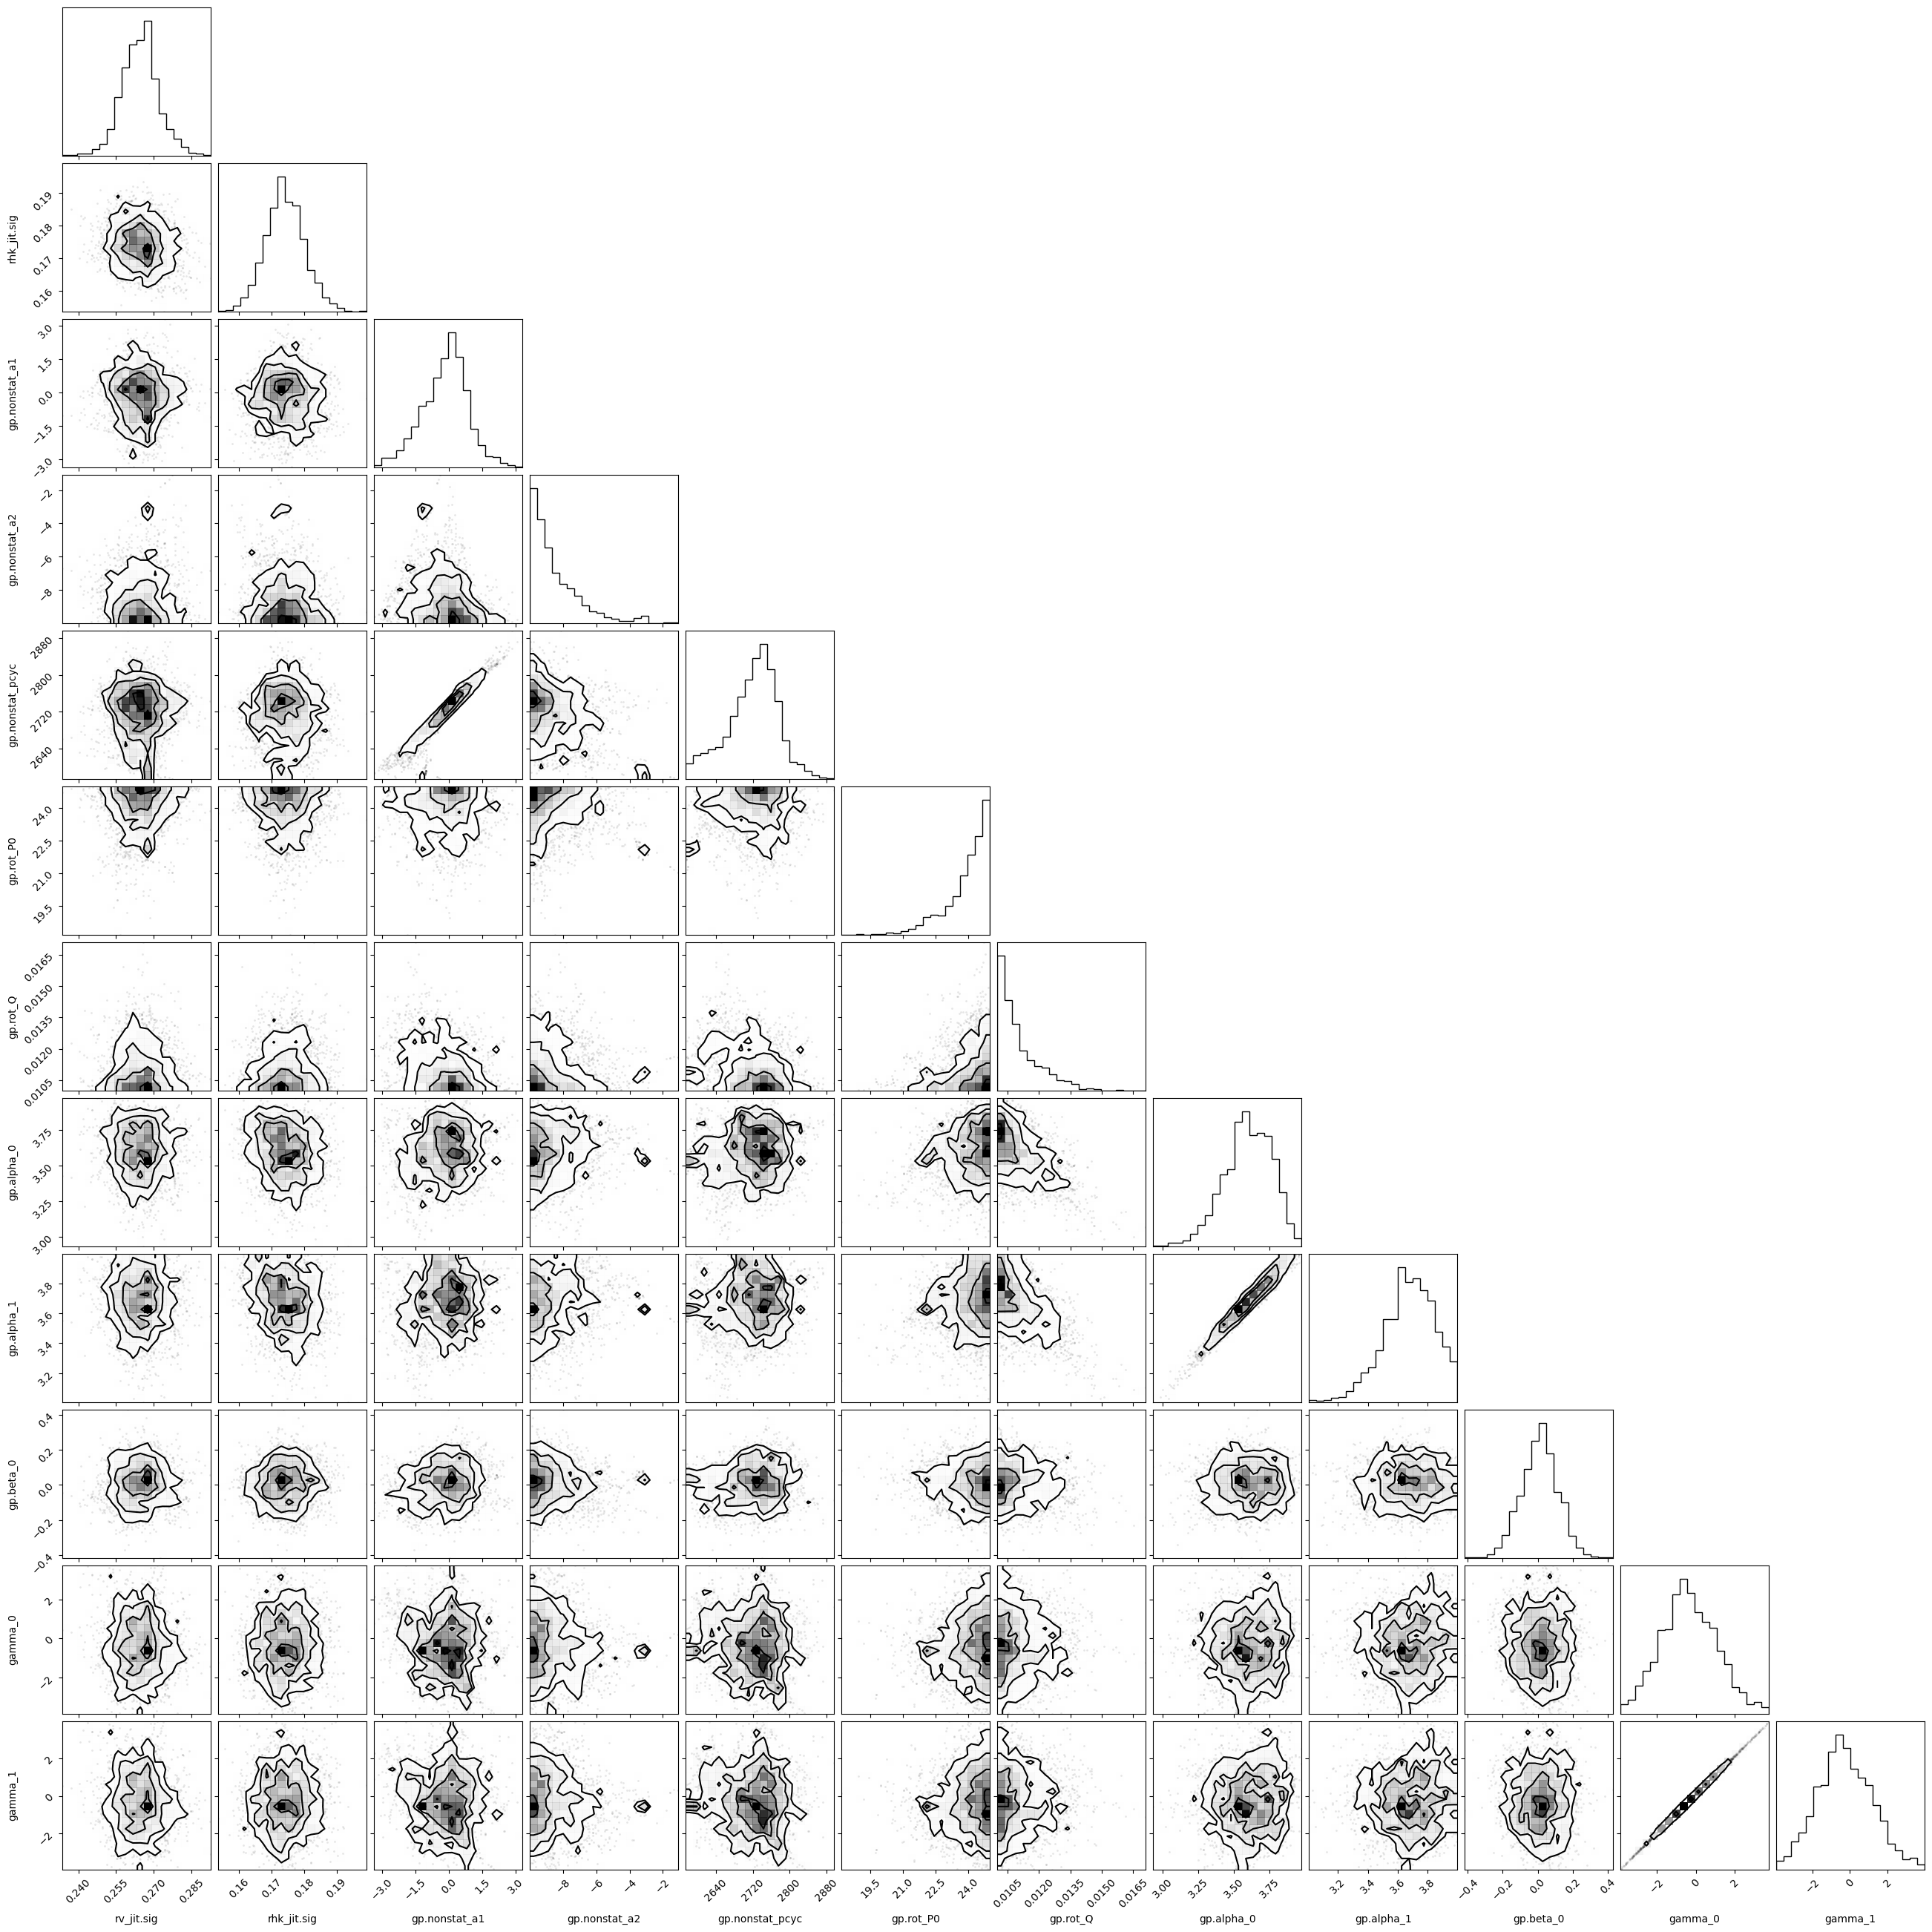

In [11]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



/var/folders/qb/bzz8k6cd16n1hv4_2j7_b3vm0000gp/T/ipykernel_53484/1436780887.py:30: RuntimeWarning: invalid value encountered in sqrt
  mu - np.sqrt(var),
/var/folders/qb/bzz8k6cd16n1hv4_2j7_b3vm0000gp/T/ipykernel_53484/1436780887.py:31: RuntimeWarning: invalid value encountered in sqrt
  mu + np.sqrt(var),


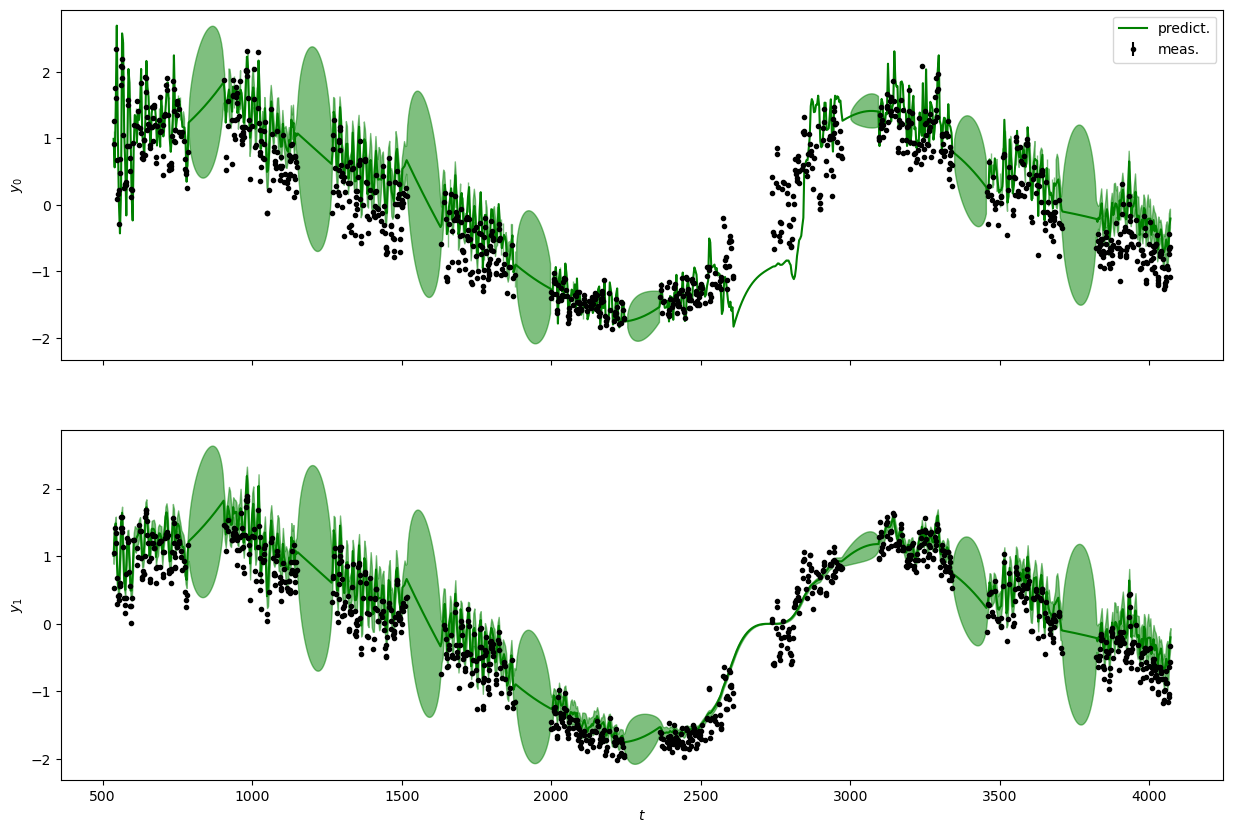

In [14]:
C.set_param(samples[-1,0,:-2],params)
C.set_param([0.0], ['gp.beta_1'])
C.set_param([np.var(y_full)], ['gp.rot_sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  fc = alpha(t_full, samples[-1,0,2],samples[-1,0,3],samples[-1,0,4])

  y_model = y_full.copy()
  y_model[series_index[0]] -= samples[-1,0,-2]*fc[series_index[0]]
  y_model[series_index[1]] -= samples[-1,0,-1]*fc[series_index[1]]
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  ax.errorbar(T[k], Y[k], Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [16]:
samples.shape

(2000, 36, 12)